In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Text(0.5, 0, 'X')

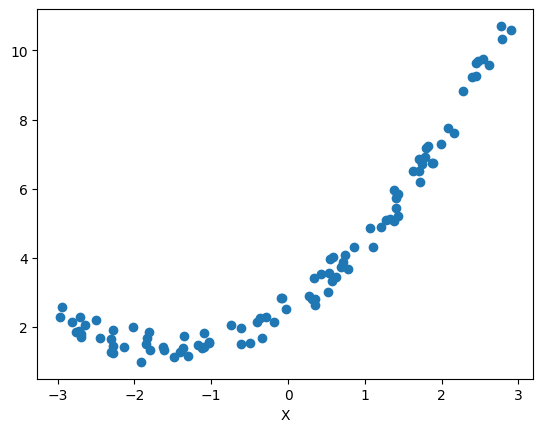

In [5]:
X = 6*np.random.rand(100, 1)-3
y = 0.5*X**2 + 1.5*X + 2 + np.random.rand(100, 1)

plt.scatter(X, y)
plt.xlabel("X")

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# Lets implement linear regression first
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
from sklearn.metrics import r2_score
y_pred = lin_reg.predict(X_test)
print("R2 Score for Linear Regression:", r2_score(y_test, y_pred))

R2 Score for Linear Regression: 0.7454702859950686


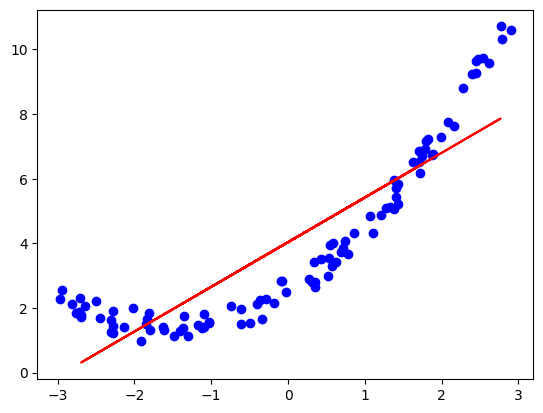

In [12]:
plt.scatter(X, y, color='blue', label='Data Points')
plt.plot(X_test, y_pred, color='red', label='Linear Fit')

In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

Mean Squared Error: 1.495207076741382
Mean Absolute Error: 1.0666726291693207
Root Mean Squared Error: 1.222786603108401


In [15]:
# lets work on polynomial regression now and compare it with linear regression
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly_train = poly_features.fit_transform(X_train)
X_poly_test = poly_features.transform(X_test)

In [17]:
lin_reg_poly = LinearRegression()
lin_reg_poly.fit(X_poly_train, y_train)
y_poly_pred = lin_reg_poly.predict(X_poly_test)
print("R2 Score for Polynomial Regression:", r2_score(y_test, y_poly_pred))

R2 Score for Polynomial Regression: 0.9909381851055593


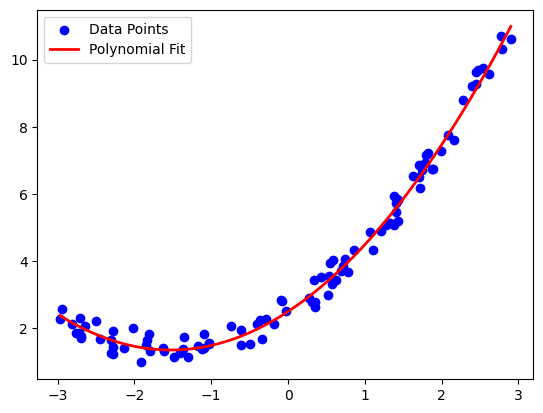

In [19]:
# Create smooth X values
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

# Transform
X_range_poly = poly_features.transform(X_range)

# Predict
y_range_pred = lin_reg_poly.predict(X_range_poly)

# Plot
plt.scatter(X, y, color='blue', label='Data Points')
plt.plot(X_range, y_range_pred, color='red', linewidth=2, label='Polynomial Fit')
plt.legend()